In [ ]:
import os
os.listdir("/content")

In [ ]:
!unzip Offroad_Segmentation_Training_Dataset.zip -d /content/dataset

unzip:  cannot find or open Offroad_Segmentation_Training_Dataset.zip, Offroad_Segmentation_Training_Dataset.zip.zip or Offroad_Segmentation_Training_Dataset.zip.ZIP.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir("/content/drive/MyDrive")

['20181125_171942.jpg',
 'form.pdf',
 'DocScanner 21 May 2023 22-07.pdf',
 'Navyam Gupta DTU',
 '20231102_003214.jpg',
 'Classroom',
 '8b346573-5f45-470e-817f-f1653009a14b.JPG',
 '8b346573-5f45-470e-817f-f1653009a14b.jpeg',
 'ccb3cc81-35cd-4c9a-b541-eac16ffd52f3.JPG',
 'IMG_2908.HEIC',
 'IMG_2909.HEIC',
 'image (1).jpg',
 'image.jpg',
 'IMG_3192.PNG',
 'IMG_3189.PNG',
 '2F216AB8-7EA6-4CCB-BA39-E9F211DAA317.MP4',
 'F3C46B82-4FCF-4064-B010-F0483FA189DB.MP4',
 '5848CCF1-78D7-4329-B007-A3392BD6664A.MP4',
 'B5AA03F0-AF80-4D50-9F25-BEB539F2F16C.MP4',
 '70A6E957-2DC5-497F-BD6C-DAC67BE24EA7.MP4',
 'B697A54B-9250-4C05-ACE3-AA19C7762B92.MP4',
 'ECA5D5BA-A75F-4F05-B123-D8908372D34A.MP4',
 '26A51901-63CE-4299-BD50-2634A01EDE25.MP4',
 '598FCBC4-E96D-44D3-B3DD-A890FC6DA4BE.MP4',
 'B604929B-3582-4D05-9D58-F5406559EE8C.MP4',
 'E5AE5298-F8DB-4592-8FDB-8E5253073226.MP4',
 '4D91D8C5-D88B-462F-BED6-125DD39C5260.MP4',
 '54984763-CDBA-4AAD-A7A3-F148FE85E424.MP4',
 'BD78902C-87DC-4543-8A59-561D31E6750D.MP4',

In [ ]:
!unzip "/content/drive/MyDrive/Offroad_Segmentation_Training_Dataset.zip" -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000123.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000124.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000125.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000126.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000127.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000128.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000129.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000130.png  
  inflating: /content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images/mt10000131.png  
  inflating: 

In [ ]:
train_dataset = SegDataset(
    "/content/dataset/Offroad_Segmentation_Training_Dataset/train/Color_Images",
    "/content/dataset/Offroad_Segmentation_Training_Dataset/train/Segmentation"
)

val_dataset = SegDataset(
    "/content/dataset/Offroad_Segmentation_Training_Dataset/val/Color_Images",
    "/content/dataset/Offroad_Segmentation_Training_Dataset/val/Segmentation"
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 2857
Val size: 317


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.2 MB/s eta 0:00:00


In [ ]:
import segmentation_models_pytorch as smp
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    classes=6,
    activation=None
)

model = model.to(device)

print("Model loaded on:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model loaded on: cuda


In [ ]:
import torch.nn as nn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

print("Loss and optimizer ready")

Loss and optimizer ready


In [ ]:
epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {avg_loss:.4f}")

Epoch 1/3, Avg Loss: 0.6936
Epoch 2/3, Avg Loss: 0.4158
Epoch 3/3, Avg Loss: 0.3595


In [ ]:
model.eval()

val_loss = 0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = loss_fn(outputs, masks)

        val_loss += loss.item()

avg_val_loss = val_loss / len(val_loader)

print("Validation Loss:", avg_val_loss)

Validation Loss: 0.33631574660539626


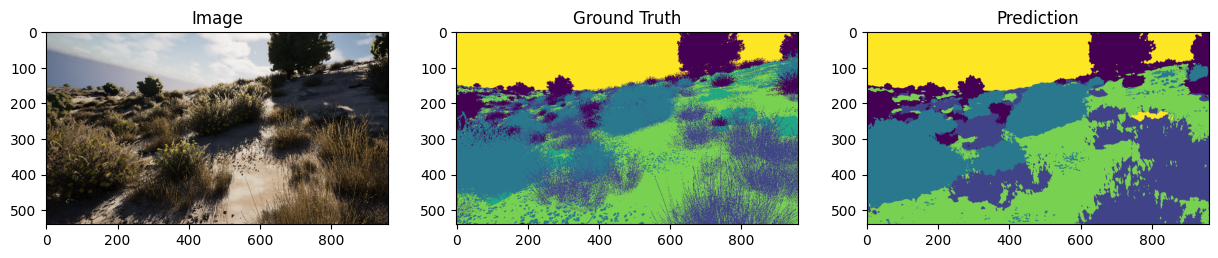

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()

images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

img = images[0].cpu().permute(1,2,0)
mask = masks[0]
pred = preds[0].cpu()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(img)

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask)

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred)

plt.show()